### import packages

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

C:\Users\10360\anaconda3\envs\py38\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\numpy\.libs\libopenblas.GK7GX5KEQ4F6UYO3P26ULGBQYHGQO7J4.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
from stAggregator import stAggregator
from stAggregator import metrics
from stAggregator.data import process_adata, process_graph
from stAggregator.data import process_graph

In [4]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [5]:
def refine_label(adata, radius=50, key='label'):
    import ot
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

In [6]:
def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])
    return adata

In [7]:
def mclust_R_smooth(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])

    adata.obs['mclust'] = refine_label(adata, 50, key='mclust')
    
    return adata

In [8]:
def clear_fig(fig):
    if fig:
        fig.axes[0].set_xlabel(None)
        fig.axes[0].set_ylabel(None)
        fig.tight_layout()
    else:
        pass
    return fig

In [9]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # 

### load data

In [10]:
adata1 = sc.read_h5ad(f'./data/breast_Xenium_sample1r1.h5ad')
adata1.obs_names_make_unique()
adata1.var_names_make_unique()
data_list = [adata1]
batch_key = 'batch'
batch_names = ['adata1']

adata = process_adata(data_list, batch_key=batch_key, batch_categories=batch_names, n_top_features=3000)
rad_cutoff_list = [15]
adata = process_graph(adata, data_list, rad_cutoff_list=rad_cutoff_list)
adata

------Calculating spatial graph...


E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)


The graph contains 650980 edges, 159226 cells.
4.0884 neighbors per cell on average.


AnnData object with n_obs × n_vars = 159226 × 313
    obs: 'UMAP_DIM1', 'UMAP_DIM2', 'Cluster', 'transcript_counts', 'x_centroid', 'y_centroid', 'gene_counts', 'cell_type', 'cell_type_sub', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'adj'
    obsm: 'spatial', 'feature_scale'
    layers: 'counts'

### train

In [21]:
path_results = f'./log/integration/'
adata_stAggregator = stAggregator(adata=adata, max_iteration=800, outdir=path_results, h_dim=16,
                       batch_size=1024, early_stop=False, random_seed=42)

Epochs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:12<00:00, 12.15s/it, recon_loss_mse=102020.213, sl1_loss=231.037, sl2_loss=233.372, lr: 0.001]
2024-06-27 21:14:38,994 - root - INFO - Output dir: ./log/integration/
2024-06-27 21:14:38,994 - root - INFO - Output dir: ./log/integration/


In [11]:
adata_stAggregator = sc.read_h5ad('./log/integration/adata_stAggregator.h5ad')
adata_stAggregator

AnnData object with n_obs × n_vars = 159226 × 313
    obs: 'UMAP_DIM1', 'UMAP_DIM2', 'Cluster', 'transcript_counts', 'x_centroid', 'y_centroid', 'gene_counts', 'cell_type', 'cell_type_sub', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial'
    layers: 'counts'

In [12]:
sc.pp.neighbors(adata_stAggregator, use_rep='X_stAggregator')

C:\Users\10360\anaconda3\envs\py38\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\umap\distances.py:1086: NumbaDeprecatio

In [13]:
sc.tl.umap(adata_stAggregator)

In [14]:
sc.tl.louvain(adata_stAggregator, resolution=0.6)

In [15]:
sc.tl.leiden(adata_stAggregator, resolution=0.4)

C:\Users\10360\anaconda3\envs\py38\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


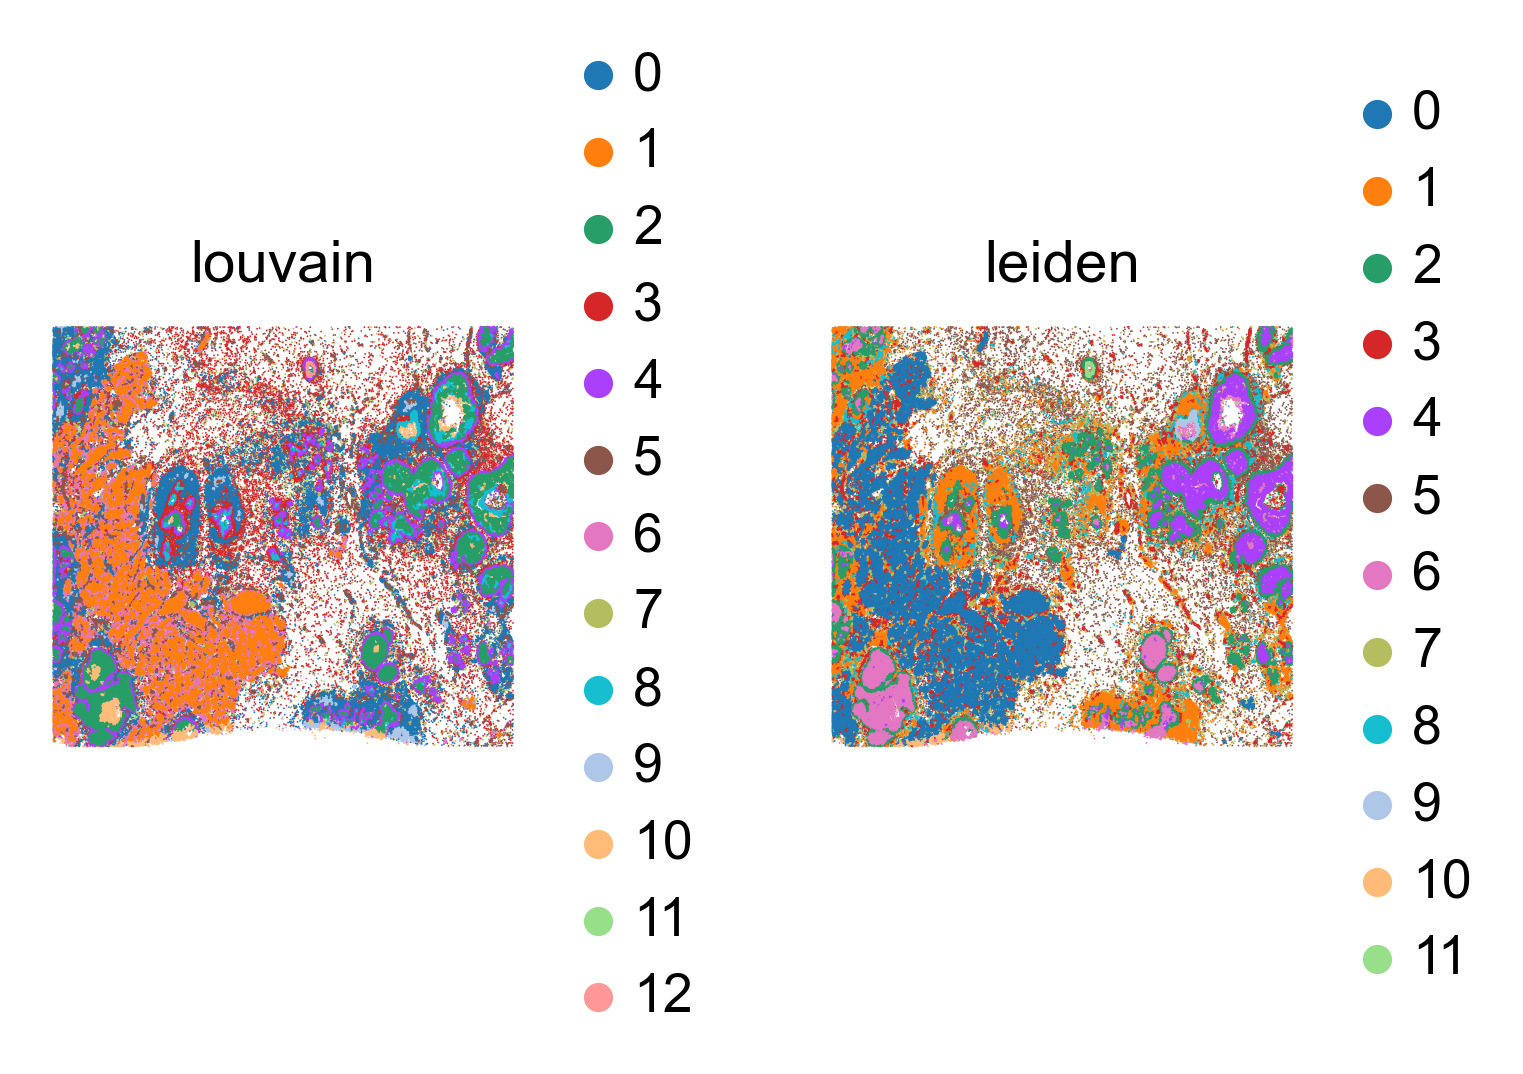

In [16]:
sc.pl.embedding(adata_stAggregator, basis='spatial', color=['louvain', 'leiden'], wspace=0.4, ncols=3)

C:\Users\10360\anaconda3\envs\py38\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\py38\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


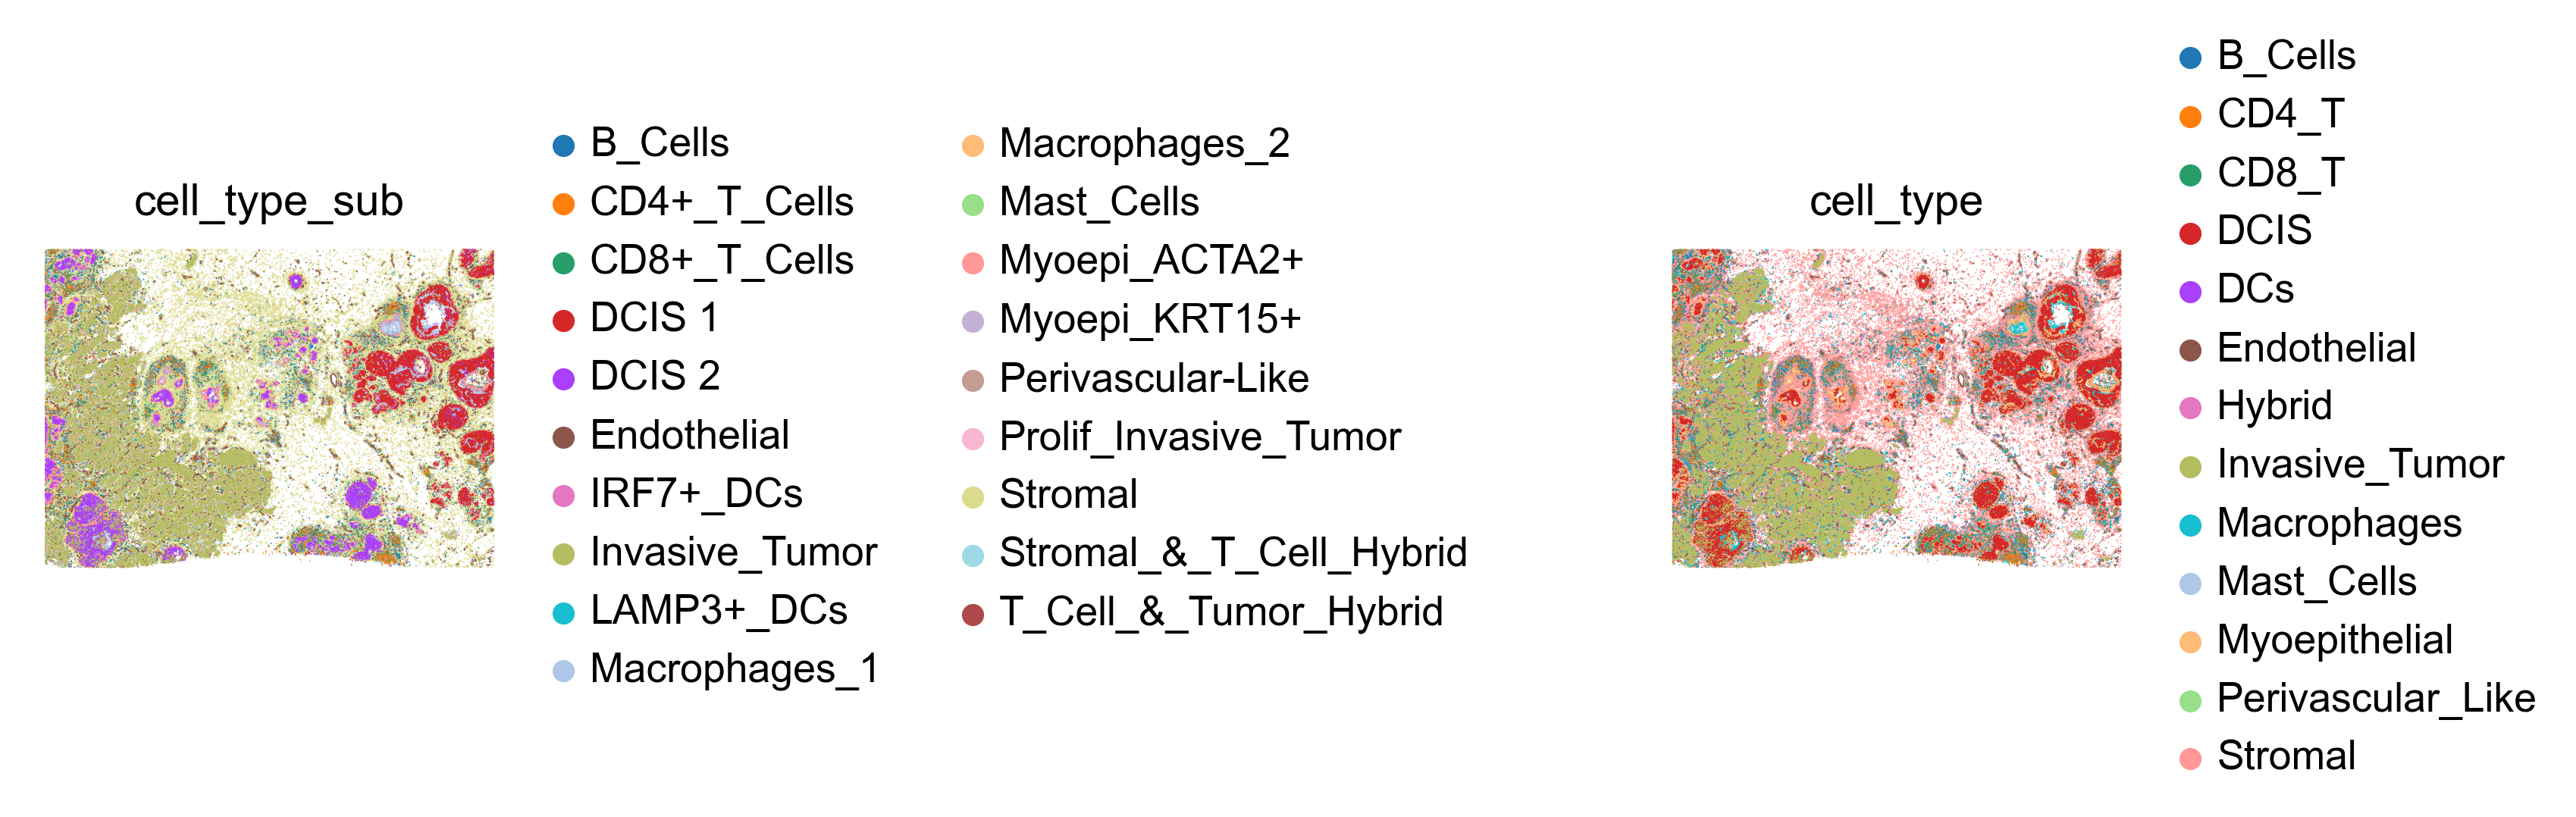

In [19]:
sc.pl.embedding(adata_stAggregator, basis='spatial', color=['cell_type_sub', 'cell_type'], wspace=2, ncols=2)